# Data Wrangling — Tiki E-commerce (2 bộ)

Nguồn: [Vietnamese Tiki E-commerce Dataset (Kaggle)](https://www.kaggle.com/datasets/michaelminhpham/vietnamese-tiki-e-commerce-dataset)

1. `vietnamese_tiki_products_men_shoes.csv` — giày nam  
2. `vietnamese_tiki_products_women_shoes.csv` — giày nữ  

Mục tiêu gốc của bộ dữ liệu: dự đoán `quantity_sold`.

Mỗi bước có **1 dòng mẫu**. Dòng `# TODO` em làm tương tự (đổi tên cột / file).

## Download data and explore

Luôn bắt đầu bằng **nhìn dữ liệu**, đừng nhảy vào `fillna`. Hỏi: bao nhiêu dòng? cột nào object? giá trị lạ (`...`, tab, rỗng)?

| Cột | Ý nghĩa |
|---|---|
| `id` | Mã sản phẩm Tiki |
| `name` | Tên sản phẩm |
| `description` | Mô tả (có thể rỗng / `...`) |
| `original_price` | Giá gốc (VND) |
| `price` | Giá hiện tại (VND) |
| `fulfillment_type` | Hình thức giao: `dropship`, `tiki_delivery`, `seller_delivery` |
| `brand` | Thương hiệu (nhiều `OEM`, đôi khi dính tab `\\tOEM`) |
| `review_count` | Số đánh giá |
| `rating_average` | Điểm trung bình (0–5; 0 thường = chưa có đánh giá) |
| `favourite_count` | Số lượt yêu thích |
| `pay_later` | Có trả sau hay không |
| `current_seller` | Tên shop |
| `date_created` | Số ngày từ lần cập nhật |
| `number_of_images` | Số ảnh |
| `vnd_cashback` | Số tiền hoàn (VND) |
| `has_video` | Có video hay không |
| `category` | Danh mục (`Root` = chưa gán danh mục rõ) |
| `quantity_sold` | Tổng số đã bán (biến mục tiêu) |

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path_men = "tiki_data/vietnamese_tiki_products_men_shoes.csv"
path_women = "tiki_data/vietnamese_tiki_products_women_shoes.csv"

df_men = pd.read_csv(path_men)  # mẫu: đọc file nam
# TODO: đọc file nữ vào df_women (giống dòng trên, đổi path_women)
df_women = None

print("Men shoes:", df_men.shape)  # mẫu: in số dòng, số cột
# TODO: in shape của df_women

df_men.head()  # mẫu: 5 dòng đầu
# TODO: xem 5 dòng đầu df_women

Men shoes: (5745, 19)


,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold
0,0,103682599,"D4 Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất...","Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ ...",9900,9900,dropship,OEM,8,3.0,0,False,Rumyh Fashion Style,829,4,268,False,Root,106
1,1,176818958,DÉP TỔ ONG ĐEN NHỰA CAO SU DẺO LOẠI ĐẸP ĐỦ SIZ...,LƯU Ý : KHÁCH MUA TỪ 5 ĐÔI TRỞ LÊN SHOP...,10000,10000,dropship,OEM,0,0.0,0,False,Tổng kho đồ gia dụng QL,504,4,0,False,Root,17
2,2,119214657,dép tổ ong huyền thoại full size,Dép Làm Chất liệu cao su tổng hợp giúp ...,9900,9900,dropship,OEM,9,3.2,0,False,sumo98 store,752,6,0,False,Root,83
3,3,164789853,Dép tổ ong đi trong nhà dày mỏng các loại,THÔNG TIN SẢN PHẨM DÉP TỔ ONG CÁC LOẠ...,24999,24999,dropship,OEM,0,0.0,0,False,Giày dép Trường Hằng,564,3,0,False,Root,0
4,4,208440729,"Dép xốp QUAI NGANG đi trong nhà/Khách sạn/Spa,...","Dép xốp quai ngang, đi trong nhà/Khách ...",14200,14200,dropship,OEM,0,0.0,0,False,TT8695,277,9,0,False,Root,0


---
# Bộ 1 — Giày nam

## 1. Xử lý giá trị thiếu (Missing Values)

- Chuỗi rỗng / `...` / `"nan"` → `NaN`.
- `fulfillment_type`, `brand`: cột phân loại → **mode**.
- `description`: điền `""` (không xoá dòng).
- `quantity_sold`: biến mục tiêu → `.dropna(subset=["quantity_sold"])`.

In [6]:
df = df_men.copy()  # mẫu: làm việc trên bản sao

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])  # mẫu: xoá cột index thừa

# TODO: xoá trùng theo id rồi reset_index — gợi ý: drop_duplicates(subset=["id"])

for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()  # mẫu: cắt khoảng trắng 2 đầu
    # TODO: trong vòng for, replace {"nan": np.nan, "": np.nan, "...": np.nan} cho df[c]

df["brand"] = df["brand"].str.replace("\t", "", regex=False)  # mẫu: xoá tab trong brand

print(df.isnull().sum())  # mẫu: đếm missing trước xử lý

df["fulfillment_type"] = df["fulfillment_type"].fillna(
    df["fulfillment_type"].mode(dropna=True)[0]
)  # mẫu: cột chữ → điền mode
# TODO: fillna mode cho cột brand (copy mẫu, đổi tên cột)

# TODO: df["description"] fillna bằng ""

# TODO: dropna subset=["quantity_sold"] rồi reset_index

# TODO: in lại isnull().sum() sau khi xử lý

id                  0
name                0
description         0
original_price      0
price               0
fulfillment_type    1
brand               0
review_count        0
rating_average      0
favourite_count     0
pay_later           0
current_seller      0
date_created        0
number_of_images    0
vnd_cashback        0
has_video           0
category            0
quantity_sold       0
dtype: int64


C:\Users\Cai Nhi\AppData\Local\Temp\ipykernel_15976\847860032.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object").columns:


In [7]:
df = df_men.copy()

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df = df.drop_duplicates(subset=['id'])
df = df.reset_index(drop=True)

for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace(['nan', '', '...'], np.nan)

df['brand'] = df['brand'].str.replace('\t', '', regex=False)

print(df.isnull().sum())
print('------------------------------------------')

df['brand'] = df['brand'].fillna(df['brand'].mode(dropna=True)[0])
df['fulfillment_type'] = df['fulfillment_type'].fillna(df['fulfillment_type'].mode(dropna=True)[0])
df['description'] = df['description'].fillna('')

df = df.dropna(subset=['quantity_sold'])
df = df.reset_index(drop=True)

print(df.isnull().sum())


id                    0
name                  0
description         258
original_price        0
price                 0
fulfillment_type      1
brand                 0
review_count          0
rating_average        0
favourite_count       0
pay_later             0
current_seller        0
date_created          0
number_of_images      0
vnd_cashback          0
has_video             0
category              0
quantity_sold         0
dtype: int64
------------------------------------------
id                  0
name                0
description         0
original_price      0
price               0
fulfillment_type    0
brand               0
review_count        0
rating_average      0
favourite_count     0
pay_later           0
current_seller      0
date_created        0
number_of_images    0
vnd_cashback        0
has_video           0
category            0
quantity_sold       0
dtype: int64


C:\Users\Cai Nhi\AppData\Local\Temp\ipykernel_15976\3153731937.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


## 2. Sửa định dạng dữ liệu (Correct Data Format)

In [8]:
print(df.dtypes)  # mẫu: xem kiểu hiện tại

df['price'] = df['price'].astype(int)
df['original_price'] = df['original_price'].astype(int)
df['quantity_sold'] = df['quantity_sold'].astype(int)
df['review_count'] = df['review_count'].astype(int)
df['rating_average'] = df['rating_average'].astype(float)

print('-----------------------------------')
print(df[['price', 'original_price', 'quantity_sold', 'review_count', 'rating_average']].dtypes)


id                    int64
name                    str
description             str
original_price        int64
price                 int64
fulfillment_type        str
brand                   str
review_count          int64
rating_average      float64
favourite_count       int64
pay_later              bool
current_seller          str
date_created          int64
number_of_images      int64
vnd_cashback          int64
has_video              bool
category                str
quantity_sold         int64
dtype: object
-----------------------------------
price               int64
original_price      int64
quantity_sold       int64
review_count        int64
rating_average    float64
dtype: object


In [9]:
print(df[['original_price', 'quantity_sold', 'review_count', 'rating_average']].dtypes)


original_price      int64
quantity_sold       int64
review_count        int64
rating_average    float64
dtype: object


ve chay lai data r chay lai lenh nay

## 3. Chuẩn hoá dữ liệu (Data Standardization)

Giá đang là **VND**. Đổi sang **nghìn đồng** cho dễ đọc, và tính **% giảm giá** so với giá gốc.

In [10]:
df['price_nghin'] = df['price'] / 1000  # mẫu: VND → nghìn đồng
df['original_price_nghin'] = df['original_price'] / 1000
df['discount_pct'] = np.where(df['original_price'] > 0, (df['original_price'] - df['price']) / df['original_price'] * 100, 0)

df[['price', 'price_nghin', 'original_price', 'original_price_nghin', 'discount_pct']].head()


,price,price_nghin,original_price,original_price_nghin,discount_pct
0,9900,9.900,9900,9.900,0.0
1,10000,10.000,10000,10.000,0.0
2,9900,9.900,9900,9.900,0.0
3,24999,24.999,24999,24.999,0.0
4,14200,14.200,14200,14.200,0.0


In [11]:
df[['price', 'price_nghin', 'original_price', 'original_price_nghin', 'discount_pct']].head()


,price,price_nghin,original_price,original_price_nghin,discount_pct
0,9900,9.900,9900,9.900,0.0
1,10000,10.000,10000,10.000,0.0
2,9900,9.900,9900,9.900,0.0
3,24999,24.999,24999,24.999,0.0
4,14200,14.200,14200,14.200,0.0


### **Giải thích `discount_pct = 0.0`:**
Cột `discount_pct` bằng `0.0` ở các sản phẩm mà `original_price` (giá gốc) bằng `price` (giá bán hiện tại). Điều này thể hiện sản phẩm đang bán đúng giá niêm yết ban đầu và không áp dụng chương trình giảm giá.

## 4. Chuẩn hoá phạm vi giá trị (Data Normalization)

`price` và `quantity_sold` lệch thang đo rất mạnh → `x / x.max()` về 0–1.

In [12]:
df['price_normalized'] = df['price'] / df['price'].max()  # mẫu: chia max → 0–1
df['quantity_sold_normalized'] = df['quantity_sold'] / df['quantity_sold'].max()
df['review_count_normalized'] = df['review_count'] / df['review_count'].max()

df[['price', 'price_normalized', 'quantity_sold', 'quantity_sold_normalized', 'review_count', 'review_count_normalized']].head()


,price,price_normalized,quantity_sold,quantity_sold_normalized,review_count,review_count_normalized
0,9900,0.000673,106,0.019525,8,0.008256
1,10000,0.000680,17,0.003131,0,0.000000
2,9900,0.000673,83,0.015288,9,0.009288
3,24999,0.001701,0,0.000000,0,0.000000
4,14200,0.000966,0,0.000000,0,0.000000


In [13]:
df[['price', 'price_normalized', 'quantity_sold', 'quantity_sold_normalized', 'review_count', 'review_count_normalized']].head()


,price,price_normalized,quantity_sold,quantity_sold_normalized,review_count,review_count_normalized
0,9900,0.000673,106,0.019525,8,0.008256
1,10000,0.000680,17,0.003131,0,0.000000
2,9900,0.000673,83,0.015288,9,0.009288
3,24999,0.001701,0,0.000000,0,0.000000
4,14200,0.000966,0,0.000000,0,0.000000


## 5. Phân nhóm (Binning)

Chia giá thành Low / Medium / High theo ngưỡng VND thực tế (không dùng min–max đều vì giá max rất lớn, hầu hết sản phẩm sẽ rơi vào Low).

price_binned
Medium    2862
Low       1855
High      1027
Name: count, dtype: int64


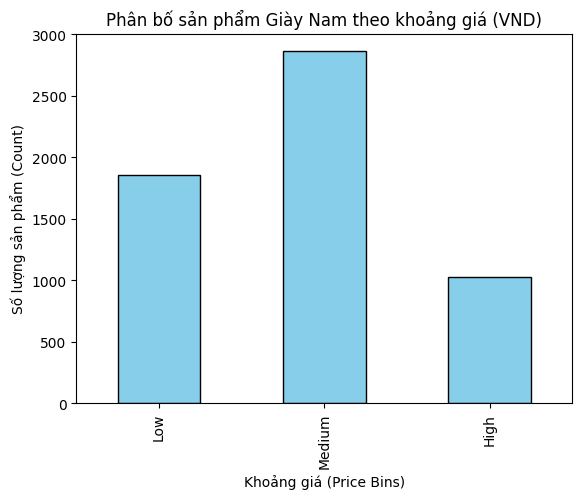

,price,price_binned
0,9900,Low
1,10000,Low
2,9900,Low
3,24999,Low
4,14200,Low


In [14]:
price_bins = [0, 100_000, 500_000, df['price'].max() + 1]
df['price_binned'] = pd.cut(df['price'], bins=price_bins, labels=['Low', 'Medium', 'High'], include_lowest=True)
print(df['price_binned'].value_counts())

df['price_binned'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Khoảng giá (Price Bins)')
plt.ylabel('Số lượng sản phẩm (Count)')
plt.title('Phân bố sản phẩm Giày Nam theo khoảng giá (VND)')
plt.show()

df[['price', 'price_binned']].head()


price_binned
Medium    2862
Low       1855
High      1027
Name: count, dtype: int64


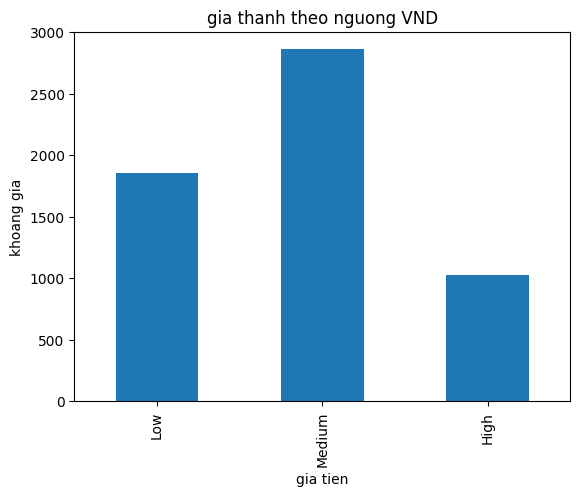

,price,price_binned
0,9900,Low
1,10000,Low
2,9900,Low
3,24999,Low
4,14200,Low


In [12]:
df[['price', 'price_binned']].head()


### **Nhận xét biểu đồ phân bố khoảng giá:**
Biểu đồ hình cột mô tả số lượng sản phẩm Giày Nam phân bố theo 3 khoảng giá: Low (0 - 100k VND), Medium (100k - 500k VND), và High (> 500k VND). Ta thấy sản phẩm tập trung chủ yếu ở phân khúc Medium và Low, trong khi phân khúc High có số lượng ít hơn.

## 6. Biến chỉ thị / Biến giả (Dummy Variable)

`fulfillment_type` (chữ) → mỗi hình thức giao một cột 0/1 bằng `pd.get_dummies()`, rồi xoá cột gốc.

In [15]:
dummy_ff = pd.get_dummies(df['fulfillment_type'], prefix='fulfillment', dtype=int)
df = pd.concat([df, dummy_ff], axis=1)
df = df.drop(columns=['fulfillment_type'])
df.head()


,id,name,description,original_price,price,brand,review_count,rating_average,favourite_count,pay_later,...,price_nghin,original_price_nghin,discount_pct,price_normalized,quantity_sold_normalized,review_count_normalized,price_binned,fulfillment_dropship,fulfillment_seller_delivery,fulfillment_tiki_delivery
0,103682599,"D4 Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất...","Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất Nh...",9900,9900,OEM,8,3.0,0,False,...,9.900,9.900,0.0,0.000673,0.019525,0.008256,Low,1,0,0
1,176818958,DÉP TỔ ONG ĐEN NHỰA CAO SU DẺO LOẠI ĐẸP ĐỦ SIZ...,LƯU Ý : KHÁCH MUA TỪ 5 ĐÔI TRỞ LÊN SHOP SẼ GIA...,10000,10000,OEM,0,0.0,0,False,...,10.000,10.000,0.0,0.000680,0.003131,0.000000,Low,1,0,0
2,119214657,dép tổ ong huyền thoại full size,Dép Làm Chất liệu cao su tổng hợp giúp dép êm ...,9900,9900,OEM,9,3.2,0,False,...,9.900,9.900,0.0,0.000673,0.015288,0.009288,Low,1,0,0
3,164789853,Dép tổ ong đi trong nhà dày mỏng các loại,THÔNG TIN SẢN PHẨM DÉP TỔ ONG CÁC LOẠI DÀY/M...,24999,24999,OEM,0,0.0,0,False,...,24.999,24.999,0.0,0.001701,0.000000,0.000000,Low,1,0,0
4,208440729,"Dép xốp QUAI NGANG đi trong nhà/Khách sạn/Spa,...","Dép xốp quai ngang, đi trong nhà/Khách sạn/Đi ...",14200,14200,OEM,0,0.0,0,False,...,14.200,14.200,0.0,0.000966,0.000000,0.000000,Low,1,0,0


In [16]:
df.head()


,id,name,description,original_price,price,brand,review_count,rating_average,favourite_count,pay_later,...,price_nghin,original_price_nghin,discount_pct,price_normalized,quantity_sold_normalized,review_count_normalized,price_binned,fulfillment_dropship,fulfillment_seller_delivery,fulfillment_tiki_delivery
0,103682599,"D4 Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất...","Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất Nh...",9900,9900,OEM,8,3.0,0,False,...,9.900,9.900,0.0,0.000673,0.019525,0.008256,Low,1,0,0
1,176818958,DÉP TỔ ONG ĐEN NHỰA CAO SU DẺO LOẠI ĐẸP ĐỦ SIZ...,LƯU Ý : KHÁCH MUA TỪ 5 ĐÔI TRỞ LÊN SHOP SẼ GIA...,10000,10000,OEM,0,0.0,0,False,...,10.000,10.000,0.0,0.000680,0.003131,0.000000,Low,1,0,0
2,119214657,dép tổ ong huyền thoại full size,Dép Làm Chất liệu cao su tổng hợp giúp dép êm ...,9900,9900,OEM,9,3.2,0,False,...,9.900,9.900,0.0,0.000673,0.015288,0.009288,Low,1,0,0
3,164789853,Dép tổ ong đi trong nhà dày mỏng các loại,THÔNG TIN SẢN PHẨM DÉP TỔ ONG CÁC LOẠI DÀY/M...,24999,24999,OEM,0,0.0,0,False,...,24.999,24.999,0.0,0.001701,0.000000,0.000000,Low,1,0,0
4,208440729,"Dép xốp QUAI NGANG đi trong nhà/Khách sạn/Spa,...","Dép xốp quai ngang, đi trong nhà/Khách sạn/Đi ...",14200,14200,OEM,0,0.0,0,False,...,14.200,14.200,0.0,0.000966,0.000000,0.000000,Low,1,0,0


### **Giải thích sự khác biệt giữa cột gốc và các cột mới:**
- **Cột gốc (`fulfillment_type`)**: Là một cột chứa văn bản dạng phân loại (string categorical, ví dụ: 'tiki_delivery', 'seller_delivery'). Các mô hình học máy (Machine Learning) không thể làm việc trực tiếp hiệu quả trên văn bản thô.
- **Các cột mới (`fulfillment_*`)**: Là các biến chỉ thị nhị phân (dummy/one-hot encoding, giá trị 0 hoặc 1). Mỗi loại hình giao hàng được tách ra thành 1 cột riêng biệt biểu thị sự hiện diện (1) hoặc không (0), giúp thuật toán dễ dàng tính toán và huấn luyện.

## Check and save

Trước khi `to_csv`:

* `isnull().sum()` còn 0 (hoặc đúng chỗ cố ý để thiếu)
* `price`, `quantity_sold` là số
* có cột mới: `price_nghin`, `*_normalized`, `price_binned`, `fulfillment_*`

`index=False` để file không thêm cột index 0,1,2,…


In [17]:
df.to_csv('tiki_men_shoes_clean.csv', index=False)
print('Kích thước tập dữ liệu Giày Nam đã làm sạch:', df.shape)
df_men_clean = df.copy()


Kích thước tập dữ liệu Giày Nam đã làm sạch: (5744, 27)


---
---
# Bộ 2 — Giày nữ

Làm **giống bộ nam**, đổi `df_men` → `df_women`. Copy mẫu ở trên, sửa tên biến. Kết thúc bằng **Check and save** (`to_csv`, `index=False`).


In [18]:
# Bộ 2 — Giày nữ: Bước 1 Xử lý giá trị thiếu
df = df_women.copy()

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df = df.drop_duplicates(subset=['id'])
df = df.reset_index(drop=True)

for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace(['nan', '', '...'], np.nan)

df['brand'] = df['brand'].str.replace('\t', '', regex=False)

df['brand'] = df['brand'].fillna(df['brand'].mode(dropna=True)[0])
df['fulfillment_type'] = df['fulfillment_type'].fillna(df['fulfillment_type'].mode(dropna=True)[0])
df['description'] = df['description'].fillna('')

df = df.dropna(subset=['quantity_sold'])
df = df.reset_index(drop=True)

print('Null sum Giày Nữ:\n', df.isnull().sum())


AttributeError: 'NoneType' object has no attribute 'copy'

In [1]:
# Bộ 2 — Giày nữ: Các bước 2, 3, 4, 5, 6 & Lưu file
# Bước 2: 
df['price'] = df['price'].astype(int)
df['original_price'] = df['original_price'].astype(int)
df['quantity_sold'] = df['quantity_sold'].astype(int)
df['review_count'] = df['review_count'].astype(int)
df['rating_average'] = df['rating_average'].astype(float)

# Bước 3: 
df['price_nghin'] = df['price'] / 1000
df['original_price_nghin'] = df['original_price'] / 1000
df['discount_pct'] = np.where(df['original_price'] > 0, (df['original_price'] - df['price']) / df['original_price'] * 100, 0)

# Bước 4: 
df['price_normalized'] = df['price'] / df['price'].max()
df['quantity_sold_normalized'] = df['quantity_sold'] / df['quantity_sold'].max()
df['review_count_normalized'] = df['review_count'] / df['review_count'].max()

# Bước 5: 
price_bins_women = [0, 100_000, 500_000, df['price'].max() + 1]
df['price_binned'] = pd.cut(df['price'], bins=price_bins_women, labels=['Low', 'Medium', 'High'], include_lowest=True)
print('Phân bố giá Giày Nữ:\n', df['price_binned'].value_counts())

df['price_binned'].value_counts().sort_index().plot(kind='bar', color='lightpink', edgecolor='black')
plt.xlabel('Khoảng giá (Price Bins)')
plt.ylabel('Số lượng sản phẩm (Count)')
plt.title('Phân bố sản phẩm Giày Nữ theo khoảng giá (VND)')
plt.show()

# Bước 6: 
dummy_ff_women = pd.get_dummies(df['fulfillment_type'], prefix='fulfillment', dtype=int)
df = pd.concat([df, dummy_ff_women], axis=1)
df = df.drop(columns=['fulfillment_type'])

df.to_csv('tiki_women_shoes_clean.csv', index=False)
print('Kích thước tập dữ liệu Giày Nữ đã làm sạch:', df.shape)
df_women_clean = df.copy()


NameError: name 'df' is not defined

In [ ]:
df_women_clean.head()


,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,...,category,quantity_sold,original_price_nghin,discount_pct,quantity_sold_normalized,review_count_normalized,price_binned,fulfillment_dropship,fulfillment_seller_delivery,fulfillment_tiki_delivery
0,103682599,"D4 Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất...","Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất Nh...",9900,9900,dropship,OEM,8,3.0,0,...,Root,106,9.900,0.0,0.019525,0.008256,Low,1,0,0
1,176818958,DÉP TỔ ONG ĐEN NHỰA CAO SU DẺO LOẠI ĐẸP ĐỦ SIZ...,LƯU Ý : KHÁCH MUA TỪ 5 ĐÔI TRỞ LÊN SHOP SẼ GIA...,10000,10000,dropship,OEM,0,0.0,0,...,Root,17,10.000,0.0,0.003131,0.000000,Low,1,0,0
2,119214657,dép tổ ong huyền thoại full size,Dép Làm Chất liệu cao su tổng hợp giúp dép êm ...,9900,9900,dropship,OEM,9,3.2,0,...,Root,83,9.900,0.0,0.015288,0.009288,Low,1,0,0
3,164789853,Dép tổ ong đi trong nhà dày mỏng các loại,THÔNG TIN SẢN PHẨM DÉP TỔ ONG CÁC LOẠI DÀY/M...,24999,24999,dropship,OEM,0,0.0,0,...,Root,0,24.999,0.0,0.000000,0.000000,Low,1,0,0
4,208440729,"Dép xốp QUAI NGANG đi trong nhà/Khách sạn/Spa,...","Dép xốp quai ngang, đi trong nhà/Khách sạn/Đi ...",14200,14200,dropship,OEM,0,0.0,0,...,Root,0,14.200,0.0,0.000000,0.000000,Low,1,0,0


promptingguide.ai -> web huong dan ky thuat prompt
ve xem Project team.pdf